In [2]:
from google.colab import files

uploaded = files.upload()

Saving archive (6).zip to archive (6).zip


In [3]:
# Part A: Dataset Preparation
import os
import zipfile
import tensorflow as tf
print("Ramya R -24BAD096")
# Find the ZIP file
zip_files = [f for f in os.listdir() if f.endswith(".zip")]
print("ZIP files found:", zip_files)

# Extract the dataset
if zip_files:
    zip_file = zip_files[0]

    with zipfile.ZipFile(zip_file, "r") as zip_ref:
        zip_ref.extractall("dataset")

    print("Dataset extracted successfully!")
else:
    print("No ZIP file found. Please upload the Kaggle ZIP file first.")

# Check dataset contents
print("Dataset contents:")
print(os.listdir("dataset"))

# Set dataset path
data_path = "dataset"
contents = os.listdir(data_path)
if len(contents) == 1 and os.path.isdir(os.path.join(data_path, contents[0])):
    data_path = os.path.join(data_path, contents[0])
print("Using dataset path:", data_path)

# Load images
dataset = tf.keras.utils.image_dataset_from_directory(
    data_path,
    image_size=(128, 128),
    batch_size=32,
    shuffle=True,
    seed=42
)
print("Classes:", dataset.class_names)
# Preprocess images
dataset = dataset.map(
    lambda images, labels: (images / 255.0, labels)
)

# Split dataset
total = tf.data.experimental.cardinality(dataset).numpy()
train_size = int(0.70 * total)
val_size = int(0.15 * total)
train_ds = dataset.take(train_size)
remaining = dataset.skip(train_size)
val_ds = remaining.take(val_size)
test_ds = remaining.skip(val_size)

# Display results
print("       DATASET PREPARATION")
print("Total batches      :", total)
print("Training batches   :", train_size)
print("Validation batches :", val_size)
print("Testing batches    :", total - train_size - val_size)
print("Image size         : 128 x 128")
print("Batch size         : 32")
print("\nDataset preparation completed!")

Ramya R -24BAD096
ZIP files found: ['archive (6).zip']
Dataset extracted successfully!
Dataset contents:
['train', 'val', 'train.csv', 'val.csv']
Using dataset path: dataset
Found 345 files belonging to 2 classes.
Classes: ['train', 'val']
       DATASET PREPARATION
Total batches      : 11
Training batches   : 7
Validation batches : 1
Testing batches    : 3
Image size         : 128 x 128
Batch size         : 32

Dataset preparation completed!


In [4]:
# Import required libraries
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

# Display student details
print("Ramya R -24BAD096")

# Load pretrained ResNet50 model
base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

# Confirm model loading
print("ResNet50 loaded successfully.")

# Freeze pretrained layers
base_model.trainable = False

# Get output from base model
x = base_model.output

# Reduce feature maps using Global Average Pooling
x = GlobalAveragePooling2D()(x)

# Add fully connected layer
x = Dense(256, activation='relu')(x)

# Add dropout layer
x = Dropout(0.5)(x)

# Add output classification layer
output = Dense(10, activation='softmax')(x)

# Create final transfer learning model
model = Model(
    inputs=base_model.input,
    outputs=output
)

# Compile the model
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Display model architecture
model.summary()

Ramya R -24BAD096
ResNet50 loaded successfully.


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer_1[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 24,114,826 (91.99 MB)

 Trainable params: 527,114 (2.01 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

7/7 ━━━━━━━━━━━━━━━━━━━━ 17s 3s/step - accuracy: 0.7946 - loss: 0.5234 - val_accuracy: 0.8125 - val_loss: 0.5367
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step - accuracy: 0.7865 - loss: 0.5941
Training Accuracy   : 0.7946428656578064
Validation Accuracy : 0.8125
Training Loss       : 0.5234185457229614
Validation Loss     : 0.5366734266281128
Test Accuracy       : 0.7865168452262878


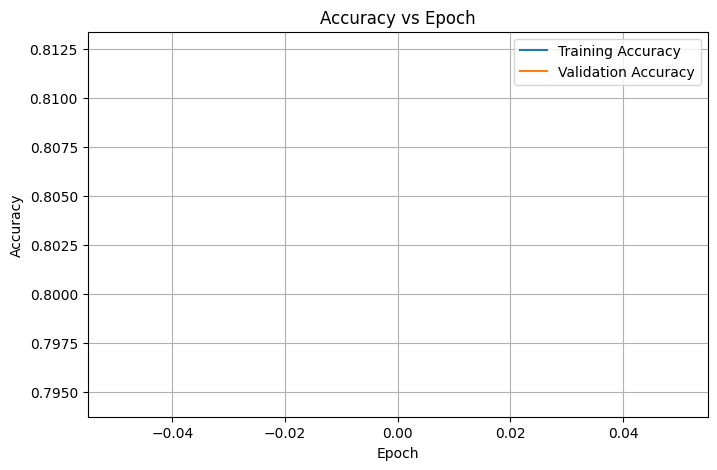

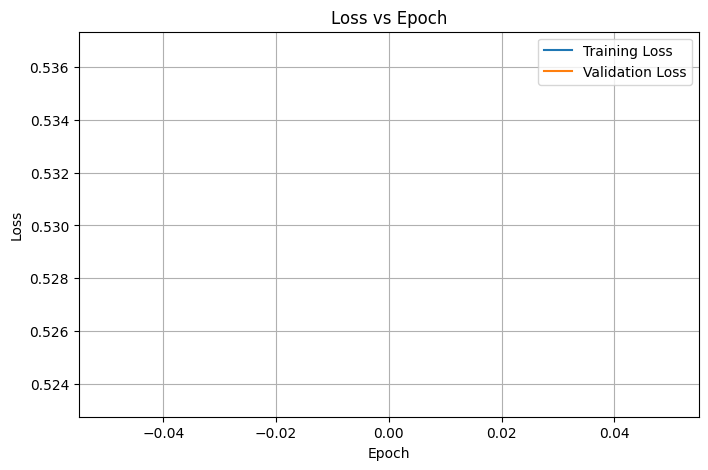

In [ ]:
# Part C: Model Training and Performance Evaluation

import matplotlib.pyplot as plt
print("Ramya R -24BAD096")
# Train the transfer learning model
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=1
)

# Record training and validation accuracy
train_accuracy = history.history["accuracy"]
val_accuracy = history.history["val_accuracy"]

# Record training and validation loss
train_loss = history.history["loss"]
val_loss = history.history["val_loss"]

# Evaluate the model on test dataset
test_loss, test_accuracy = model.evaluate(test_ds)

# Display performance results
print("Training Accuracy   :", train_accuracy[-1])
print("Validation Accuracy :", val_accuracy[-1])
print("Training Loss       :", train_loss[-1])
print("Validation Loss     :", val_loss[-1])
print("Test Accuracy       :", test_accuracy)


# Plot Accuracy vs Epoch
plt.figure(figsize=(8, 5))
plt.plot(train_accuracy, label="Training Accuracy")
plt.plot(val_accuracy, label="Validation Accuracy")
plt.title("Accuracy vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid()
plt.show()


# Plot Loss vs Epoch
plt.figure(figsize=(8, 5))
plt.plot(train_loss, label="Training Loss")
plt.plot(val_loss, label="Validation Loss")
plt.title("Loss vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid()
plt.show()

Ramya R - 24BAD096
Ramya R - 24BAD096


Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

Hugging Face model loaded successfully.

Hugging Face Predictions
------------------------
Image 1 : Leonberg
Image 2 : kelpie
Image 3 : Persian cat
Image 4 : Pomeranian
Image 5 : soft-coated wheaten terrier

Transfer Learning Model Predictions
-----------------------------------
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 727ms/step
Image 1 : dogs
Image 2 : dogs
Image 3 : dogs
Image 4 : dogs
Image 5 : dogs


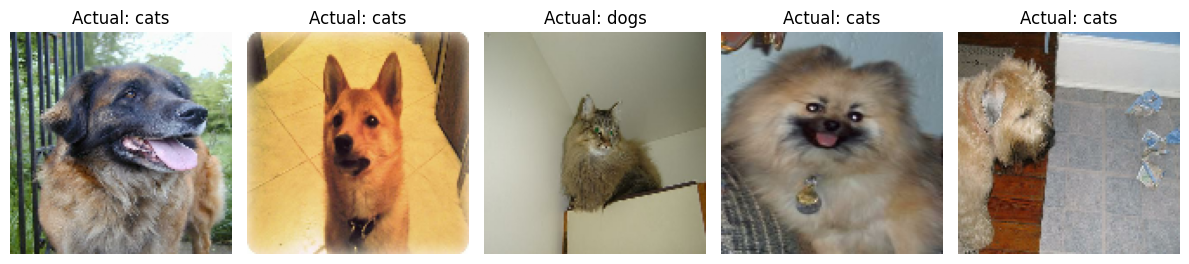


Observations
------------
1. A pre-trained vision model was loaded from Hugging Face.
2. Sample images were classified using the Hugging Face model.
3. The same images were classified using the ResNet50 transfer learning model.
4. The predictions from both models were compared.
5. The actual class labels were displayed with the sample images.
6. ResNet50 was trained specifically for the cats and dogs dataset.
7. The Hugging Face Vision Transformer was pre-trained on ImageNet.


In [11]:

# PART D: USING HUGGING FACE PRE-TRAINED MODELS

# Install Hugging Face Transformers
!pip install -q transformers

# Import required libraries
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from transformers import pipeline

print("Ramya R - 24BAD096")
# Display student details
print("Ramya R - 24BAD096")

# Define class names
class_names = ["cats", "dogs"]

# Load a pre-trained vision model from Hugging Face
classifier = pipeline(
    "image-classification",
    model="google/vit-base-patch16-224"
)

# Display model loading message
print("Hugging Face model loaded successfully.")

# Get sample images from the test dataset
for images, labels in test_ds.take(1):
    sample_images = images[:5]
    sample_labels = labels[:5]

# Display Hugging Face prediction heading
print("\nHugging Face Predictions")
print("------------------------")

# Perform image classification on sample images
huggingface_predictions = []

for i in range(5):

    # Convert image to NumPy format
    image = sample_images[i].numpy()

    # Convert pixel values from 0-1 to 0-255
    image = (image * 255).astype(np.uint8)

    # Perform prediction using Hugging Face
    prediction = classifier(image)

    # Store prediction
    huggingface_predictions.append(
        prediction[0]["label"]
    )

    # Display prediction
    print(
        "Image", i + 1,
        ":", prediction[0]["label"]
    )

# Resize sample images for ResNet50
sample_images_resized = tf.image.resize(
    sample_images,
    (224, 224)
)

# Convert resized images to NumPy format
sample_images_resized = np.array(
    sample_images_resized
)

# Display transfer learning prediction heading
print("\nTransfer Learning Model Predictions")
print("-----------------------------------")

# Perform prediction using ResNet50
predictions = model.predict(
    sample_images_resized
)

# Get predicted class indexes
predicted_classes = np.argmax(
    predictions,
    axis=1
)

# Display ResNet50 predictions
for i in range(5):

    print(
        "Image", i + 1,
        ":", class_names[
            int(predicted_classes[i])
        ]
    )

# Display sample images
plt.figure(figsize=(12, 5))

for i in range(5):

    # Create subplot
    plt.subplot(1, 5, i + 1)

    # Display image
    plt.imshow(sample_images[i])

    # Display actual class
    plt.title(
        "Actual: " +
        class_names[
            int(sample_labels[i])
        ]
    )

    # Hide axes
    plt.axis("off")

# Display all images
plt.tight_layout()
plt.show()

# Document observations
print("\nObservations")
print("------------")

print("1. A pre-trained vision model was loaded from Hugging Face.")
print("2. Sample images were classified using the Hugging Face model.")
print("3. The same images were classified using the ResNet50 transfer learning model.")
print("4. The predictions from both models were compared.")
print("5. The actual class labels were displayed with the sample images.")
print("6. ResNet50 was trained specifically for the cats and dogs dataset.")
print("7. The Hugging Face Vision Transformer was pre-trained on ImageNet.")